In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gc

# import user-defined files
from utils import Reservoir, DataGenerator
from methods import evaluate_metrics
from recursive_inference import recursive_inference

## Training

Example of training and testing

In [3]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [4]:
data = torch.from_numpy(mat_file['tseries']).float()

Compute the metrics to evaluate the results

## Random search

We now want to try to optimize the architecture by tuning the hyperparameters of the system, in particular we vary:
- Spectral radius of $W$
- Number of neurons
- Reservoir's activation function
- Adam's learning rate
- Sampled weights variance

## Best model

## Load best model

In [5]:
# decomment if reading from file:
best_params = pd.read_csv("best_parameters.csv")

In [6]:
pyro.clear_param_store()

In [7]:
best_params = best_params.set_index('parameter')['value']

In [16]:
# fetch test dataset
data_test = torch.from_numpy(sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

In [17]:
# Generate Torch datasets
test_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

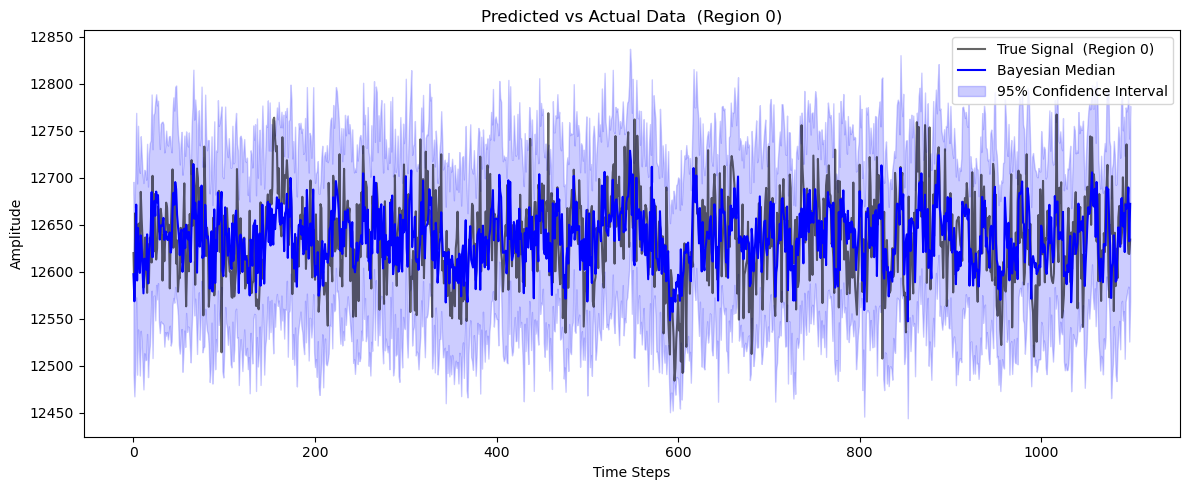

In [18]:
# predict
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000)

In [19]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized avergae
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [20]:
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")

Empirical Coverage: 0.956 ± 0.002
Calibration Error:  0.00036 ± 0.00003
mCRPS (Normalized): 0.0904 ± 0.0009


## Visualizations

## heatmap mCRPS

## Recursive forecasting